In [90]:
import pandas as pd
import kagglehub
import os


In [91]:
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Dataset downloaded to path:", path)
files = os.listdir(path)
print("Files available:", files)
csv_file = [f for f in files if f.endswith('.csv')][0] # Grabs the first CSV found
df = pd.read_csv(os.path.join(path, csv_file))

Dataset downloaded to path: C:\Users\lenovo\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
Files available: ['housing.csv']


In [92]:
import pandas as pd
import numpy as np

In [93]:
def shuffle_split (data,ratio):
    np.random.seed(42)
    shuffled_index = np.random.permutation(len(data))
    test_size = int(len(data)*ratio)
    test_index = shuffled_index[:test_size]
    train_idex = shuffled_index[test_size:]
    return data.iloc[test_index],data.iloc[train_idex]


In [94]:
df['income category'] = pd.cut(df['median_income'],bins = [0,2,5,10,20,np.inf],labels= ['0-2','2-5','5-10','10-20','>20'])

In [70]:
# Shuffle Test Function

In [95]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, train_size=.2,random_state=42)


In [96]:
for train_index, test_index in split.split(df,df['income category']):
    train_data = df.loc[train_index]
    test_data = df.loc[test_index]

In [99]:
test_data.drop(columns = 'income category',inplace=True)
train_data.drop(columns = 'income category',inplace=True)


In [112]:
df_train = train_data.copy()
df_test = test_data.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

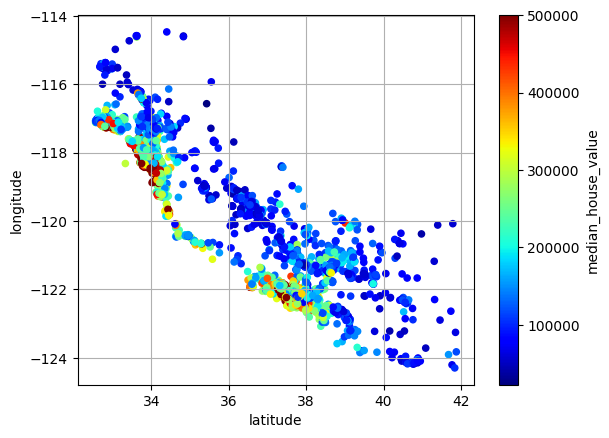

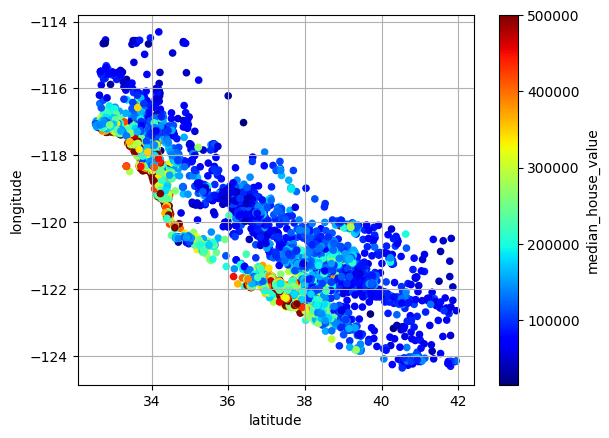

In [115]:
df_train.plot(kind = "scatter",x ="latitude",y = "longitude",grid = True , c ="median_house_value",cmap = 'jet' )
df_test.plot(kind = "scatter",x ="latitude",y = "longitude",grid = True ,  c = 'median_house_value',cmap = 'jet')